In [1]:
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from typing import List, Tuple

# Запуск JVM
jpype.startJVM(classpath=[".."])

# Импорт Java-классов
ShoppingOptimizer = jpype.JClass("utils.shopping.ShoppingOptimizer")
Item = jpype.JClass("utils.shopping.ShoppingOptimizer$Item")
ArrayList = jpype.JClass("java.util.ArrayList")

In [ ]:
def test_example():
    """Тестовый пример с конкретными данными"""
    # Создаем оптимизатор
    optimizer = ShoppingOptimizer()
    
    # Создаем список товаров
    items_list = ArrayList()
    items = [
        Item("Тетрадь", 25.0, 5),
        Item("Ручка", 15.0, 3),
        Item("Карандаш", 10.0, 4),
        Item("Линейка", 30.0, 1),
        Item("Ластик", 20.0, 2),
        Item("Циркуль", 50.0, 1),
        Item("Пенал", 100.0, 1),
        Item("Маркер", 40.0, 2)
    ]
    for item in items:
        items_list.add(item)
    
    # Задаем бюджет
    budget = 200.0
    
    print("\nТестовый пример:")
    print(f"Бюджет: {budget} руб.")
    print("\nСписок товаров:")
    for item in items:
        print(f"- {item}")
    
    # Оптимизируем покупки
    result = optimizer.optimize(items_list, budget)
    
    print("\nРезультаты оптимизации:")
    print(f"Потрачено: {result.totalSpent:.2f} руб.")
    print(f"Осталось: {result.remainingBudget:.2f} руб.")
    print(f"Количество различных товаров: {result.uniqueItemsPurchased}")
    print(f"Время выполнения: {result.executionTime} нс")
    
    print("\nКупленные товары:")
    for item in result.items:
        if item.purchased > 0:
            print(f"- {item}")

def generate_random_items(n: int) -> ArrayList:
    """Генерация случайного списка товаров"""
    items_list = ArrayList()
    names = [f"Товар_{i}" for i in range(n)]
    
    for name in names:
        price = random.uniform(10.0, 100.0)
        required = random.randint(1, 5)
        items_list.add(Item(name, price, required))
    
    return items_list

def analyze_performance():
    """Анализ производительности алгоритма"""
    optimizer = ShoppingOptimizer()
    
    # Параметры тестирования
    n_values = [10, 50, 100, 500, 1000]  # размеры списков товаров
    budget_ratios = [0.2, 0.5, 1.0]      # отношение бюджета к сумме всех товаров
    iterations = 5                        # количество повторений для усреднения
    
    results = []
    
    print("\nАнализ производительности:")
    
    for n in n_values:
        print(f"\nТестирование для {n} товаров...")
        
        for ratio in budget_ratios:
            execution_times = []
            unique_items_ratios = []
            
            for _ in range(iterations):
                items = generate_random_items(n)
                total_cost = sum(item.price * item.required for item in items)
                budget = total_cost * ratio
                

                result = optimizer.optimize(items, budget)
                
                execution_times.append(result.executionTime)
                unique_items_ratios.append(result.uniqueItemsPurchased / n)
            
            results.append({
                'n': n,
                'budget_ratio': ratio,
                'avg_time': np.mean(execution_times),
                'std_time': np.std(execution_times),
                'avg_unique_ratio': np.mean(unique_items_ratios),
                'std_unique_ratio': np.std(unique_items_ratios)
            })
    
    df = pd.DataFrame(results)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    for ratio in budget_ratios:
        data = df[df['budget_ratio'] == ratio]
        plt.errorbar(data['n'], data['avg_time'] / 1e6, 
                    yerr=data['std_time'] / 1e6,
                    label=f'Бюджет {ratio:.1f}x', marker='o')
    
    plt.xlabel('Количество товаров')
    plt.ylabel('Время выполнения (мс)')
    plt.title('Зависимость времени выполнения\nот размера входных данных')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for ratio in budget_ratios:
        data = df[df['budget_ratio'] == ratio]
        plt.errorbar(data['n'], data['avg_unique_ratio'] * 100,
                    yerr=data['std_unique_ratio'] * 100,
                    label=f'Бюджет {ratio:.1f}x', marker='o')
    
    plt.xlabel('Количество товаров')
    plt.ylabel('Доля купленных товаров (%)')
    plt.title('Зависимость доли купленных товаров\nот размера входных данных')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("\nРезультаты тестирования:")
    df['avg_time'] /= 1e6  
    df['avg_unique_ratio'] *= 100  
    print(df.to_string(float_format=lambda x: '{:.2f}'.format(x)))

def main():
    test_example()
    analyze_performance()


Тестовый пример:
Бюджет: 200.0 руб.

Список товаров:
- Тетрадь (цена: 25,00 руб., требуется: 5, куплено: 0)
- Ручка (цена: 15,00 руб., требуется: 3, куплено: 0)
- Карандаш (цена: 10,00 руб., требуется: 4, куплено: 0)
- Линейка (цена: 30,00 руб., требуется: 1, куплено: 0)
- Ластик (цена: 20,00 руб., требуется: 2, куплено: 0)
- Циркуль (цена: 50,00 руб., требуется: 1, куплено: 0)
- Пенал (цена: 100,00 руб., требуется: 1, куплено: 0)
- Маркер (цена: 40,00 руб., требуется: 2, куплено: 0)

Результаты оптимизации:
Потрачено: 200.00 руб.
Осталось: 0.00 руб.
Количество различных товаров: 7
Время выполнения: 1475800 нс

Купленные товары:
- Карандаш (цена: 10,00 руб., требуется: 4, куплено: 2)
- Ручка (цена: 15,00 руб., требуется: 3, куплено: 1)
- Ластик (цена: 20,00 руб., требуется: 2, куплено: 1)
- Тетрадь (цена: 25,00 руб., требуется: 5, куплено: 1)
- Линейка (цена: 30,00 руб., требуется: 1, куплено: 1)
- Маркер (цена: 40,00 руб., требуется: 2, куплено: 1)
- Циркуль (цена: 50,00 руб., требуе

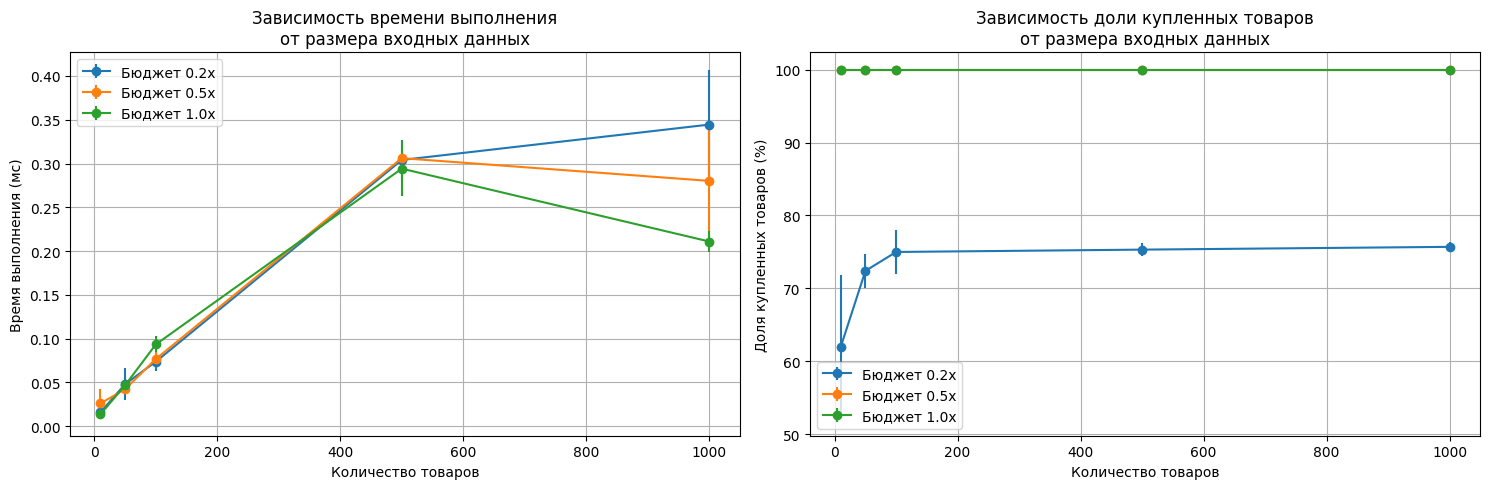


Результаты тестирования:
       n  budget_ratio  avg_time  std_time  avg_unique_ratio  std_unique_ratio
0     10          0.20      0.02    770.97             62.00              0.10
1     10          0.50      0.03  17009.10            100.00              0.00
2     10          1.00      0.01   2798.14            100.00              0.00
3     50          0.20      0.05  18527.71             72.40              0.02
4     50          0.50      0.04   4378.77            100.00              0.00
5     50          1.00      0.05   4630.51            100.00              0.00
6    100          0.20      0.07  10714.59             75.00              0.03
7    100          0.50      0.08   7901.75            100.00              0.00
8    100          1.00      0.09   9224.84            100.00              0.00
9    500          0.20      0.30  22991.01             75.32              0.01
10   500          0.50      0.31   6924.91            100.00              0.00
11   500          1.00    

In [3]:
main()